In [ ]:
"""
STEP 1 (Google Colab + Drive version) — Run this ONCE per Colab session.
Prepares a shared, leakage-safe, balanced dataset for all models.

CHANGE FROM PREVIOUS VERSION:
    Val split now uses a PER-CLASS fraction instead of one shared VAL_FRACTION.
    Fraud gets a much bigger slice (e.g. 30%) of its small original pool so
    the val set has enough Fraud examples (~60 instead of ~30) for stable
    val_auc / val_f1 during training. Non-Fraud keeps a small fraction since
    it already has plenty of images either way.
"""

import os
import shutil
import zipfile
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img

from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = "/content/drive/MyDrive"
RAW_ZIP_PATH = os.path.join(DRIVE_ROOT, "Insurance-Fraud-Detection.zip")
RAW_DIR_ON_DRIVE = os.path.join(DRIVE_ROOT, "Insurance-Fraud-Detection")
PROCESSED_OUT_DIR_ON_DRIVE = os.path.join(DRIVE_ROOT, "Insurance-Fraud-Detection-Processed")

LOCAL_ROOT = "/content"
BASE_DIR = os.path.join(LOCAL_ROOT, "Insurance-Fraud-Detection")
SRC_TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")
BALANCED_TRAIN_DIR = os.path.join(BASE_DIR, "train_balanced")

IMG_SIZE = (224, 224)
SEED = 42

# --- KEY CHANGE: per-class val fraction instead of one shared value ---
# Fraud: take 30% of the ~200 originals -> ~60 val images (was ~30 at 15%)
# Non-Fraud: keep 15% -> plenty either way, no need to change
VAL_FRACTION_BY_CLASS = {
    "Fraud": 0.30,
    "Non-Fraud": 0.15,
}

AUG_CAP_MULTIPLIER = 10  # keep whatever value you were already using


def stage_raw_dataset_locally():
    if os.path.exists(BASE_DIR):
        print(f"{BASE_DIR} already exists locally, skipping copy.")
        return
    if os.path.exists(RAW_ZIP_PATH):
        print(f"Unzipping {RAW_ZIP_PATH} -> {LOCAL_ROOT} ...")
        with zipfile.ZipFile(RAW_ZIP_PATH, "r") as zf:
            zf.extractall(LOCAL_ROOT)
    elif os.path.exists(RAW_DIR_ON_DRIVE):
        print(f"Copying {RAW_DIR_ON_DRIVE} -> {BASE_DIR} ...")
        shutil.copytree(RAW_DIR_ON_DRIVE, BASE_DIR)
    else:
        raise FileNotFoundError(
            f"Could not find dataset at:\n  {RAW_ZIP_PATH}\n  {RAW_DIR_ON_DRIVE}"
        )
    assert os.path.exists(SRC_TRAIN_DIR), f"Expected {SRC_TRAIN_DIR} after staging."
    print("Raw dataset staged locally at:", BASE_DIR)


def split_train_val(src_train_dir, val_dir, img_size=IMG_SIZE,
                     val_fraction_by_class=VAL_FRACTION_BY_CLASS, seed=SEED):
    """Stratified split of ORIGINAL images, using a different val fraction
    per class so the minority class isn't left with too few val examples."""
    if os.path.exists(val_dir):
        shutil.rmtree(val_dir)

    classes = sorted(os.listdir(src_train_dir))
    train_pool = {}

    for cls in classes:
        cls_dir = os.path.join(src_train_dir, cls)
        files = sorted(os.listdir(cls_dir))

        val_fraction = val_fraction_by_class.get(cls, 0.15)  # default fallback

        train_files, val_files = train_test_split(
            files, test_size=val_fraction, random_state=seed, shuffle=True
        )

        val_cls_dir = os.path.join(val_dir, cls)
        os.makedirs(val_cls_dir, exist_ok=True)
        for f in val_files:
            img = load_img(os.path.join(cls_dir, f), target_size=img_size)
            img.save(os.path.join(val_cls_dir, f))

        train_pool[cls] = [os.path.join(cls_dir, f) for f in train_files]
        print(f"{cls}: val_fraction={val_fraction} -> {len(train_files)} train pool, {len(val_files)} val/")

    return train_pool


def build_balanced_train_dir(train_pool, dst_dir, img_size=IMG_SIZE,
                              aug_cap_multiplier=AUG_CAP_MULTIPLIER, seed=SEED):
    """Same as before: copy originals, then augment minority class up to a
    capped multiplier of its own size (not all the way to match majority),
    so you don't over-rely on augmentation from very few unique Fraud photos."""
    np.random.seed(seed)
    if os.path.exists(dst_dir):
        shutil.rmtree(dst_dir)

    aug = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        zoom_range=0.15,
        brightness_range=(0.85, 1.15),
        horizontal_flip=True,
        fill_mode="nearest",
    )

    counts = {c: len(files) for c, files in train_pool.items()}
    minority_cls = min(counts, key=counts.get)
    target_count = counts[minority_cls] * aug_cap_multiplier
    print(f"Train-pool counts (post-split): {counts}")
    print(f"Capping '{minority_cls}' augmentation at {aug_cap_multiplier}x -> target {target_count}")

    for cls, files in train_pool.items():
        dst_cls_dir = os.path.join(dst_dir, cls)
        os.makedirs(dst_cls_dir, exist_ok=True)

        for f in files:
            img = load_img(f, target_size=img_size)
            img.save(os.path.join(dst_cls_dir, os.path.basename(f)))

        this_target = target_count if cls == minority_cls else len(files)
        n_needed = this_target - len(files)
        if n_needed <= 0:
            continue

        print(f"  Generating {n_needed} augmented images for '{cls}'...")
        i = 0
        while i < n_needed:
            src_file = files[i % len(files)]
            img = load_img(src_file, target_size=img_size)
            x = np.expand_dims(img_to_array(img), axis=0)
            for batch in aug.flow(x, batch_size=1, seed=seed + i):
                array_to_img(batch[0]).save(
                    os.path.join(dst_cls_dir, f"aug_{i}_{os.path.basename(src_file)}")
                )
                i += 1
                break

    final_counts = {c: len(os.listdir(os.path.join(dst_dir, c))) for c in train_pool}
    print("Balanced train_balanced/ counts:", final_counts)


def verify(src_train_dir=SRC_TRAIN_DIR, val_dir=VAL_DIR, balanced_dir=BALANCED_TRAIN_DIR):
    classes = sorted(os.listdir(src_train_dir))

    orig_counts = {c: len(os.listdir(os.path.join(src_train_dir, c))) for c in classes}
    bal_counts = {c: len(os.listdir(os.path.join(balanced_dir, c))) for c in classes}
    val_counts = {c: len(os.listdir(os.path.join(val_dir, c))) for c in classes}

    orig_ratio = max(orig_counts.values()) / min(orig_counts.values())
    bal_ratio = max(bal_counts.values()) / min(bal_counts.values())

    assert bal_ratio < orig_ratio, (
        f"train_balanced/ did not improve class balance: orig_ratio={orig_ratio:.1f}, bal_ratio={bal_ratio:.1f}"
    )

    for cls in classes:
        val_files = set(os.listdir(os.path.join(val_dir, cls)))
        bal_files = set(os.listdir(os.path.join(balanced_dir, cls)))
        leaked = val_files.intersection(bal_files)
        assert not leaked, f"Leakage detected in '{cls}': {list(leaked)[:5]}"

    for cls in classes:
        sample_bal = os.listdir(os.path.join(balanced_dir, cls))[0]
        assert load_img(os.path.join(balanced_dir, cls, sample_bal)).size == IMG_SIZE
        sample_val = os.listdir(os.path.join(val_dir, cls))[0]
        assert load_img(os.path.join(val_dir, cls, sample_val)).size == IMG_SIZE

    for cls in classes:
        assert len(os.listdir(os.path.join(src_train_dir, cls))) > 0

    print("\nAll checks passed:")
    print(f"  - class imbalance improved: orig ratio {orig_ratio:.1f}:1 -> balanced ratio {bal_ratio:.1f}:1")
    print(f"  - val/ counts per class: {val_counts}   <-- check Fraud is now ~60, not ~30")
    print("  - no exact filename leakage between val/ and train_balanced/")
    print(f"  - all images resized to {IMG_SIZE}")
    print("  - original train/ left untouched")


def upload_results_to_drive(base_dir=BASE_DIR, out_dir=PROCESSED_OUT_DIR_ON_DRIVE):
    os.makedirs(out_dir, exist_ok=True)
    for folder_name in ["train_balanced", "val"]:
        src = os.path.join(base_dir, folder_name)
        zip_base = os.path.join(LOCAL_ROOT, folder_name)
        print(f"Zipping {src} ...")
        shutil.make_archive(zip_base, "zip", src)
        dst_zip = os.path.join(out_dir, f"{folder_name}.zip")
        shutil.copy(f"{zip_base}.zip", dst_zip)
        print(f"  -> saved to {dst_zip}")
    print("\nUpload complete.")


if __name__ == "__main__":
    stage_raw_dataset_locally()
    train_pool = split_train_val(SRC_TRAIN_DIR, VAL_DIR)
    build_balanced_train_dir(train_pool, BALANCED_TRAIN_DIR)
    verify()
    upload_results_to_drive()
    print("\nDone. Local: train_balanced/ and val/ under", BASE_DIR)
    print("Drive copy: ", PROCESSED_OUT_DIR_ON_DRIVE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/Insurance-Fraud-Detection already exists locally, skipping copy.
Fraud: val_fraction=0.3 -> 140 train pool, 60 val/
Non-Fraud: val_fraction=0.15 -> 4250 train pool, 750 val/
Train-pool counts (post-split): {'Fraud': 140, 'Non-Fraud': 4250}
Capping 'Fraud' augmentation at 10x -> target 1400
  Generating 1260 augmented images for 'Fraud'...
Balanced train_balanced/ counts: {'Fraud': 1400, 'Non-Fraud': 4250}

All checks passed:
  - class imbalance improved: orig ratio 25.0:1 -> balanced ratio 3.0:1
  - val/ counts per class: {'Fraud': 60, 'Non-Fraud': 750}   <-- check Fraud is now ~60, not ~30
  - no exact filename leakage between val/ and train_balanced/
  - all images resized to (224, 224)
  - original train/ left untouched
Zipping /content/Insurance-Fraud-Detection/train_balanced ...
  -> saved to /content/drive/MyDrive/Insurance-Fraud-Detection-Proc

In [ ]:
import os
for cls in ['Fraud', 'Non-Fraud']:
    print(cls, len(os.listdir(f'/content/Insurance-Fraud-Detection/train/{cls}')))

Fraud 200
Non-Fraud 5000


In [ ]:
import hashlib
import os
from PIL import Image

def check_real_leakage(val_dir, train_dir, exclude_aug_prefix="aug_"):
    """
    Detects real image leakage between val/ and train_balanced/ by comparing
    pixel content (MD5 hash of decoded pixels), not filenames. Catches cases
    where the same photo appears under two different filenames in the raw
    dataset. Skips aug_* files since those are synthetic derivatives.
    """
    def pixel_hash(path):
        with Image.open(path) as img:
            img = img.convert("RGB")
            return hashlib.md5(img.tobytes()).hexdigest()

    classes = sorted(os.listdir(val_dir))
    total_leaks = 0

    for cls in classes:
        val_cls_dir = os.path.join(val_dir, cls)
        train_cls_dir = os.path.join(train_dir, cls)

        val_hashes = {pixel_hash(os.path.join(val_cls_dir, f)): f
                      for f in os.listdir(val_cls_dir)}

        train_files = [f for f in os.listdir(train_cls_dir)
                       if not f.startswith(exclude_aug_prefix)]

        leaks = []
        for f in train_files:
            h = pixel_hash(os.path.join(train_cls_dir, f))
            if h in val_hashes:
                leaks.append((val_hashes[h], f))

        if leaks:
            print(f"[{cls}] LEAKAGE: {len(leaks)} image(s) appear in both val/ and train_balanced/ under different filenames:")
            for v, t in leaks[:10]:
                print(f"    val/{cls}/{v}  <->  train_balanced/{cls}/{t}")
            total_leaks += len(leaks)
        else:
            print(f"[{cls}] OK — 0 pixel-identical matches "
                  f"(checked {len(train_files)} non-aug train files vs {len(val_hashes)} val files)")

    print(f"\n{'⚠️  Total leaked images: ' + str(total_leaks) if total_leaks else 'No real (content-level) leakage detected.'}")
    return total_leaks

In [ ]:
check_real_leakage(
    "/content/Insurance-Fraud-Detection/val",
    "/content/Insurance-Fraud-Detection/train_balanced"
)

[Fraud] OK — 0 pixel-identical matches (checked 140 non-aug train files vs 60 val files)
[Non-Fraud] OK — 0 pixel-identical matches (checked 4250 non-aug train files vs 750 val files)

No real (content-level) leakage detected.


0

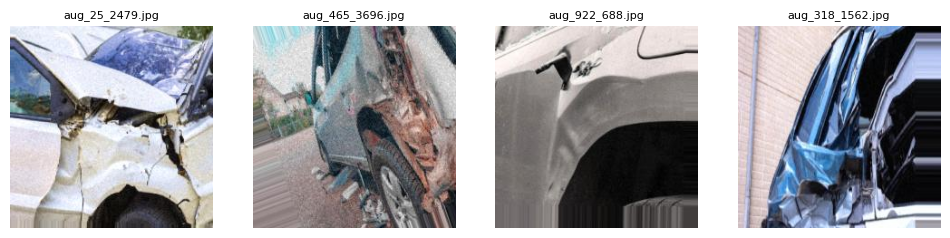

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

fraud_dir = "/content/Insurance-Fraud-Detection/train_balanced/Fraud"
aug_files = [f for f in os.listdir(fraud_dir) if f.startswith("aug_")][:4]

fig, axes = plt.subplots(1, len(aug_files), figsize=(12,3))
for ax, f in zip(axes, aug_files):
    ax.imshow(load_img(os.path.join(fraud_dir, f)))
    ax.set_title(f, fontsize=8)
    ax.axis('off')
plt.show()

In [ ]:
import json

train_dir = "/content/Insurance-Fraud-Detection/train_balanced"
counts = {c: len(os.listdir(os.path.join(train_dir, c))) for c in os.listdir(train_dir)}
total = sum(counts.values())
n_classes = len(counts)

class_weights = {c: total / (n_classes * n) for c, n in counts.items()}
print(class_weights)

with open("/content/Insurance-Fraud-Detection/class_weights.json", "w") as f:
    json.dump(class_weights, f, indent=2)

shutil.copy(
    "/content/Insurance-Fraud-Detection/class_weights.json",
    "/content/drive/MyDrive/Insurance-Fraud-Detection-Processed/class_weights.json"
)

{'Fraud': 2.017857142857143, 'Non-Fraud': 0.6647058823529411}


'/content/drive/MyDrive/Insurance-Fraud-Detection-Processed/class_weights.json'

In [ ]:
import hashlib, os

def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

def check_real_leakage(val_dir, balanced_dir):
    classes = sorted(os.listdir(val_dir))
    for cls in classes:
        val_hashes = {
            file_hash(os.path.join(val_dir, cls, f)): f
            for f in os.listdir(os.path.join(val_dir, cls))
        }
        leaked = []
        for f in os.listdir(os.path.join(balanced_dir, cls)):
            h = file_hash(os.path.join(balanced_dir, cls, f))
            if h in val_hashes:
                leaked.append((f, val_hashes[h]))
        if leaked:
            print(f"[{cls}] REAL leakage — {len(leaked)} identical images:")
            for bal_f, val_f in leaked[:10]:
                print(f"    train_balanced/{bal_f}  ==  val/{val_f}")
        else:
            print(f"[{cls}] clean — no identical images between val/ and train_balanced/")

check_real_leakage("Insurance-Fraud-Detection/val", "Insurance-Fraud-Detection/train_balanced")

[Fraud] clean — no identical images between val/ and train_balanced/
[Non-Fraud] clean — no identical images between val/ and train_balanced/


In [ ]:
import shutil
shutil.make_archive( '/content/drive/MyDrive/Insurance-Fraud-Detection-Processed/test', 'zip', '/content/drive/MyDrive/Insurance-Fraud-Detection/test' )

'/content/drive/MyDrive/Insurance-Fraud-Detection-Processed/test.zip'